# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 10: HYBRID FUSION MODEL
# ============================================================
# Purpose:
# This notebook combines the structured model branch and the
# improved audio CNN branch into a final hybrid genre
# classification model.
#
# The goal is to:
# 1. Load probability outputs from the structured model
# 2. Load probability outputs from the improved audio CNN
# 3. Fuse the two probability vectors
# 4. Evaluate hybrid performance on validation and test sets
# 5. Compare structured-only, CNN-only, and hybrid results
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 

In [2]:
# ============================================================
# 2. LOAD STRUCTURED MODEL OUTPUTS
# ============================================================

val_probs_rf = np.load("../data/processed/val_probs_rf.npy")
structured_test_probs = np.load("../data/processed/structured_test_probs_best.npy")

y_val_structured = np.load("../data/processed/y_val_structured.npy")
y_test_structured = np.load("../data/processed/y_test_structured.npy")

structured_classes = np.load("../data/processed/structured_label_classes.npy", allow_pickle=True)

with open("../data/processed/best_structured_model_name.txt", "r") as f:
    best_structured_model_name = f.read()

with open("../data/processed/best_structured_model_test_accuracy.txt", "r") as f:
    structured_test_accuracy = float(f.read())

print("Best structured model:", best_structured_model_name)
print("Structured test accuracy:", structured_test_accuracy)
print("Structured classes:", structured_classes)

Best structured model: Random Forest
Structured test accuracy: 0.4053333333333333
Structured classes: ['Classical' 'Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'Pop' 'Rock']


In [3]:
# ============================================================
# 3. LOAD CNN OUTPUTS
# ============================================================

val_probs_cnn = np.load("../data/processed/val_probs_cnn.npy")
test_probs_cnn = np.load("../data/processed/test_probs_cnn.npy")

y_val_cnn = np.load("../data/processed/y_val_cnn.npy")
y_test_cnn = np.load("../data/processed/y_test_cnn.npy")

cnn_classes = np.load("../data/processed/cnn_label_classes.npy", allow_pickle=True)

with open("../data/processed/improved_cnn_test_accuracy.txt", "r") as f:
    improved_cnn_test_accuracy = float(f.read())

print("CNN test accuracy:", improved_cnn_test_accuracy)
print("CNN classes:", cnn_classes)

CNN test accuracy: 0.4533333480358124
CNN classes: ['Classical' 'Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'Pop' 'Rock']


In [4]:
# ============================================================
# 4. CHECK ALIGNMENT
# ============================================================

print("Validation labels match:", np.array_equal(y_val_structured, y_val_cnn))
print("Test labels match:", np.array_equal(y_test_structured, y_test_cnn))
print("Class labels match:", np.array_equal(structured_classes, cnn_classes))

Validation labels match: True
Test labels match: True
Class labels match: True


In [5]:
# ============================================================
# 5. DEFINE FUSION FUNCTION
# ============================================================

def fuse_probabilities(probs_structured, probs_cnn, w_structured=0.5, w_cnn=0.5):
    return (w_structured * probs_structured) + (w_cnn * probs_cnn)

In [6]:
# ============================================================
# 6. TRY DIFFERENT FUSION WEIGHTS ON VALIDATION SET
# ============================================================

fusion_results = []

weight_options = [
    (0.1, 0.9),
    (0.2, 0.8),
    (0.3, 0.7),
    (0.4, 0.6),
    (0.5, 0.5),
    (0.6, 0.4),
    (0.7, 0.3),
    (0.8, 0.2),
    (0.9, 0.1),
]

for w_structured, w_cnn in weight_options:
    fused_val_probs = fuse_probabilities(
        val_probs_rf,
        val_probs_cnn,
        w_structured=w_structured,
        w_cnn=w_cnn
    )

    fused_val_pred = np.argmax(fused_val_probs, axis=1)
    fused_val_acc = accuracy_score(y_val_structured, fused_val_pred)

    fusion_results.append({
        "Structured Weight": w_structured,
        "CNN Weight": w_cnn,
        "Validation Accuracy": fused_val_acc
    })

fusion_results_df = pd.DataFrame(fusion_results)

print("Fusion Validation Results:")
display(fusion_results_df.sort_values("Validation Accuracy", ascending=False))

Fusion Validation Results:


,Structured Weight,CNN Weight,Validation Accuracy
5,0.6,0.4,0.558011
6,0.7,0.3,0.555249
3,0.4,0.6,0.552486
4,0.5,0.5,0.546961
7,0.8,0.2,0.544199
2,0.3,0.7,0.538674
1,0.2,0.8,0.530387
0,0.1,0.9,0.524862
8,0.9,0.1,0.516575


In [7]:
# ============================================================
# 7. SELECT BEST FUSION WEIGHTS
# ============================================================

best_row = fusion_results_df.sort_values("Validation Accuracy", ascending=False).iloc[0]

best_w_structured = best_row["Structured Weight"]
best_w_cnn = best_row["CNN Weight"]
best_fusion_val_acc = best_row["Validation Accuracy"]

print("Best fusion weights:")
print("Structured weight:", best_w_structured)
print("CNN weight:", best_w_cnn)
print("Best fusion validation accuracy:", best_fusion_val_acc)

Best fusion weights:
Structured weight: 0.6
CNN weight: 0.4
Best fusion validation accuracy: 0.5580110497237569


In [8]:
# ============================================================
# 8. EVALUATE HYBRID MODEL ON TEST SET
# ============================================================

hybrid_test_probs = fuse_probabilities(
    structured_test_probs,
    test_probs_cnn,
    w_structured=best_w_structured,
    w_cnn=best_w_cnn
)

hybrid_test_pred = np.argmax(hybrid_test_probs, axis=1)
hybrid_test_accuracy = accuracy_score(y_test_structured, hybrid_test_pred)

print("Hybrid Test Accuracy:", hybrid_test_accuracy)

Hybrid Test Accuracy: 0.4613333333333333


In [9]:
# ============================================================
# 9. HYBRID CLASSIFICATION REPORT
# ============================================================

print(classification_report(
    y_test_structured,
    hybrid_test_pred,
    target_names=structured_classes,
    zero_division=0
))

              precision    recall  f1-score   support

   Classical       0.69      0.72      0.71        25
  Electronic       0.42      0.50      0.45        50
Experimental       0.38      0.28      0.32        50
        Folk       0.33      0.46      0.38        50
     Hip-Hop       0.69      0.94      0.80        50
Instrumental       0.24      0.14      0.18        50
         Pop       0.30      0.14      0.19        50
        Rock       0.52      0.64      0.57        50

    accuracy                           0.46       375
   macro avg       0.45      0.48      0.45       375
weighted avg       0.43      0.46      0.43       375



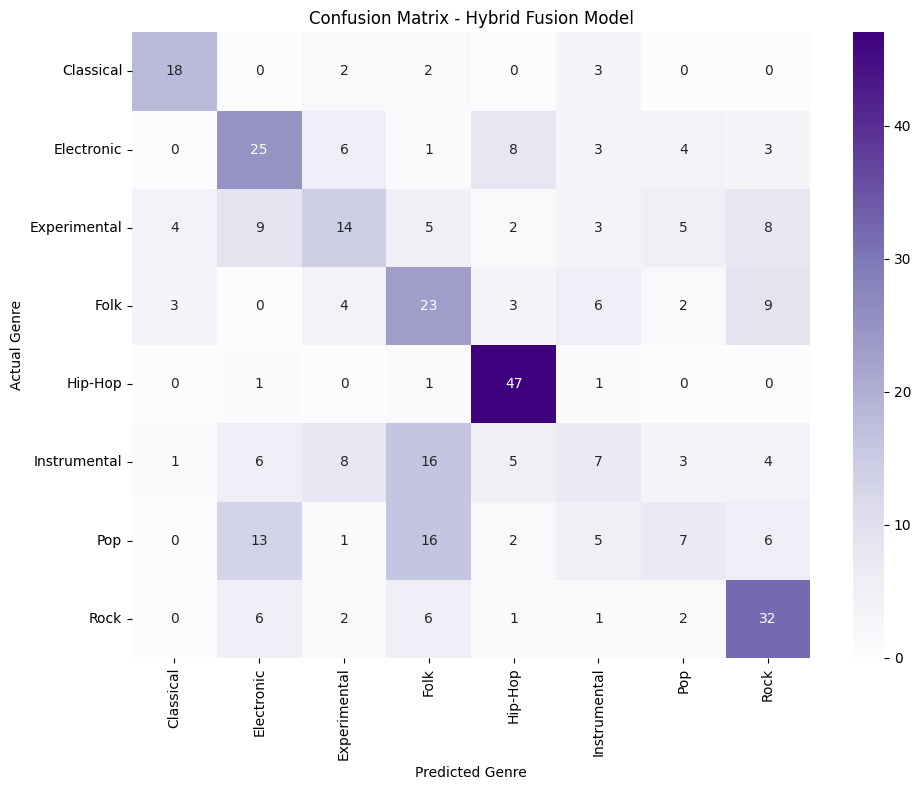

In [10]:
# ============================================================
# 10. HYBRID CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test_structured, hybrid_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=structured_classes,
    yticklabels=structured_classes
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix - Hybrid Fusion Model")
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# 11. FINAL MODEL COMPARISON
# ============================================================

final_comparison = pd.DataFrame({
    "Model": [
        "Best Structured Model",
        "Improved Audio CNN",
        "Hybrid Fusion Model"
    ],
    "Test Accuracy": [
        structured_test_accuracy,
        improved_cnn_test_accuracy,
        hybrid_test_accuracy
    ]
})

print("Final Model Comparison:")
display(final_comparison)

Final Model Comparison:


,Model,Test Accuracy
0,Best Structured Model,0.405333
1,Improved Audio CNN,0.453333
2,Hybrid Fusion Model,0.461333


In [12]:
# ============================================================
# 12. SAVE HYBRID RESULTS
# ============================================================

os.makedirs("../data/processed", exist_ok=True)

with open("../data/processed/hybrid_test_accuracy.txt", "w") as f:
    f.write(str(hybrid_test_accuracy))

final_comparison.to_csv("../data/processed/final_model_comparison.csv", index=False)

print("Saved hybrid results.")

Saved hybrid results.


In [13]:
# ============================================================
# 13. INTERPRETATION NOTES
# ============================================================

print("1. This notebook combines the structured and unstructured branches into a hybrid classifier.")
print("2. Fusion is performed by combining probability outputs from both models.")
print("3. Validation data is used to select the best weighting between the two branches.")
print("4. The final hybrid result shows whether combining engineered features and CNN-based spectrogram learning improves prediction.")
print("5. This hybrid stage is the closest representation of the intended final genre prediction system.")

1. This notebook combines the structured and unstructured branches into a hybrid classifier.
2. Fusion is performed by combining probability outputs from both models.
3. Validation data is used to select the best weighting between the two branches.
4. The final hybrid result shows whether combining engineered features and CNN-based spectrogram learning improves prediction.
5. This hybrid stage is the closest representation of the intended final genre prediction system.
